# 손 bbox 크롭 저장 — RSNA 전체 배치

학습한 `best.pt`로 원본 12,611장에서 손 영역을 검출해 **bbox 크기 그대로 잘라 저장**합니다.

```
C:\Users\Win11Pro\Desktop\뼈데이터\전처리\train\
├── images/            # 크롭된 이미지 (원본 파일명 유지: 1377.png ...)
├── preview/           # 원본+박스 / 크롭 나란히 붙인 검수용 이미지
├── crop_log.csv       # 전체 크롭 기록 (bbox 좌표·conf·QC 플래그)
├── crop_failed.csv    # 검출 실패 + QC 플래그 케이스만
└── errors.txt         # 읽기/저장 예외 목록
```

| Part | 내용 |
|---|---|
| 0 | 환경 + 경로 설정 (한글 경로 안전 I/O) |
| 1 | 모델 로드 (`best.pt` 자동 탐색) |
| 2 | **설정값** ← 여기만 고쳐서 재실행 |
| 3 | 예행 실행 6장 — 자르기 전 눈으로 확인 |
| 4 | 전체 배치 크롭 저장 |
| 5 | 결과 통계 + 크롭 사이즈 분포 |
| 6 | 실패·QC 케이스 검수 |

**설계 원칙 3가지**
1. **`MARGIN = 0.0`이 기본** — 요청대로 bbox 크기 그대로 자릅니다. 손가락 끝이 잘리면 0.03~0.05로 올리세요.
2. **검출 실패를 조용히 넘기지 않습니다** — `no_det`는 원본 전체를 저장하고 CSV에 반드시 기록합니다. 파일 개수만 맞고 내용이 틀린 상황(기존 전처리의 무음 버그 패턴)을 원천 차단합니다.
3. **원본 파일명 유지** — `boneage-training-dataset.csv`의 `id` 컬럼과 그대로 조인됩니다. 기존 DataLoader의 경로만 바꾸면 됩니다.


## Part 0. 환경 + 경로 설정

In [1]:
import sys, os, json, time, shutil
from pathlib import Path
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor

import numpy as np, pandas as pd, cv2, torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from tqdm.auto import tqdm

# ─── 경로 ───────────────────────────────────────────────────────
SRC_DIR  = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터\Bone+Age+Test+Set")
BASE_OUT = Path(r"C:\Users\Win11Pro\Desktop\뼈데이터\전처리\test")

CROP_DIR    = BASE_OUT / "images"     # 크롭 결과 (BASE_OUT 으로 바꾸면 평면 저장)
PREVIEW_DIR = BASE_OUT / "preview"    # 검수용 비교 이미지
for d in (BASE_OUT, CROP_DIR, PREVIEW_DIR):
    d.mkdir(parents=True, exist_ok=True)

IMG_EXT = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# ─── 한글 경로 안전 I/O ─────────────────────────────────────────
def imread_u(path, flags=cv2.IMREAD_GRAYSCALE):
    """cv2.imread는 Windows 비ASCII 경로에서 None을 반환하며 무음 실패"""
    img = cv2.imdecode(np.fromfile(str(path), dtype=np.uint8), flags)
    if img is None:
        raise IOError(f"디코드 실패: {path}")
    return img

def imwrite_u(path, img, quality=None):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or ".png"
    params = [int(cv2.IMWRITE_JPEG_QUALITY), quality] if (quality and ext.lower() in (".jpg", ".jpeg")) else []
    ok, buf = cv2.imencode(ext, img, params)
    if not ok:
        raise IOError(f"인코딩 실패: {path}")
    buf.tofile(str(path))

def to_bgr(im):
    """YOLO predict는 3채널 HWC 입력 전제 → 흑백 2D 배열 변환"""
    return cv2.cvtColor(im, cv2.COLOR_GRAY2BGR) if im.ndim == 2 else im

# ─── 점검 ───────────────────────────────────────────────────────
print("Python:", sys.version.split()[0], "| Torch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

assert SRC_DIR.exists(), f"원본 경로 없음: {SRC_DIR}"
FILES = sorted([p for p in SRC_DIR.rglob("*") if p.suffix.lower() in IMG_EXT])
assert FILES, f"이미지가 없습니다: {SRC_DIR}"

_t = imread_u(FILES[0])
print(f"\n원본 {len(FILES):,}장  ← {SRC_DIR}")
print(f"읽기 테스트: {FILES[0].name}  shape={_t.shape}  dtype={_t.dtype}")
print(f"저장 위치  : {CROP_DIR}")


Python: 3.11.9 | Torch: 2.12.0.dev20260408+cu128 | CUDA: True
GPU   : NVIDIA GeForce RTX 5060 Laptop GPU

원본 200장  ← C:\Users\Win11Pro\Desktop\뼈데이터\Bone+Age+Test+Set
읽기 테스트: 4360.png  shape=(1414, 999)  dtype=uint8
저장 위치  : C:\Users\Win11Pro\Desktop\뼈데이터\전처리\test\images


## Part 1. 모델 로드

`MODEL_PT`를 직접 지정하거나, `None`이면 `best.pt`를 자동 탐색해 **가장 최근 파일**을 씁니다.
학습을 다른 PC에서 했다면 `best.pt`만 복사해 오고 경로를 지정하세요.


In [2]:
MODEL_PT = None
# 예: MODEL_PT = Path(r"C:\work\hand_det\runs\hand_yolo26n_640\weights\best.pt")

SEARCH_ROOTS = [Path(r"C:\work\hand_det\runs"), BASE_OUT.parent, Path.cwd()]

if MODEL_PT is None:
    cands = [p for root in SEARCH_ROOTS if root.exists() for p in root.rglob("best.pt")]
    if not cands:
        raise FileNotFoundError(
            "best.pt를 찾지 못했습니다. MODEL_PT에 직접 경로를 넣으세요.\n"
            f"탐색 위치: {[str(r) for r in SEARCH_ROOTS]}")
    MODEL_PT = max(cands, key=lambda p: p.stat().st_mtime)

MODEL_PT = Path(MODEL_PT)
assert MODEL_PT.exists(), f"가중치 없음: {MODEL_PT}"

det = YOLO(str(MODEL_PT))
CLASS_NAMES = det.names

print("가중치   :", MODEL_PT)
print("수정시각 :", datetime.fromtimestamp(MODEL_PT.stat().st_mtime).strftime("%Y-%m-%d %H:%M"))
print("클래스   :", CLASS_NAMES)


가중치   : C:\work\hand_det\runs\hand_yolo26n_640\weights\best.pt
수정시각 : 2026-07-28 08:59
클래스   : {0: 'item'}


## Part 2. 설정값

| 설정 | 기본값 | 근거 |
|---|---|---|
| `MARGIN` | **0.0** | 요청대로 bbox 크기 그대로. 잘림이 보이면 0.03~0.05 |
| `CONF_TH` | 0.25 | 낮게 두고 QC로 거르는 편이 미검출보다 안전 |
| `NO_DET_POLICY` | `"full"` | 검출 실패 시 원본 전체 저장 + 플래그. `"skip"`이면 저장 안 함 |
| `OUT_SIZE` | `None` | 크롭 원본 해상도 유지. 학습 해상도로 고정하려면 512 등 |
| `SQUARE_PAD` | False | `OUT_SIZE` 지정 시 종횡비 유지 + 검은 패딩 여부 |
| `SAVE_EXT` | `".png"` | 무손실. 의료영상은 JPG 압축 아티팩트를 피하는 게 원칙 |
| `BATCH` | 16 | VRAM 부족하면 8 |
| `SKIP_EXISTING` | True | 중단 후 재실행 시 이어서 진행 |
| `LIMIT` | None | 예행 실행 시 50 등으로 지정 |

**QC 플래그** — `no_det` / `low_conf` / `small_box` / `huge_box` / `odd_aspect` / `touch_border` / `multi_det`

> `huge_box`는 예전 `_adv_select_hand()`가 바깥 밝은 프레임을 손으로 오인하던 것과 같은 실패 패턴입니다. 검출기로 바꿔도 이 지표는 계속 감시하세요.


In [3]:
# ═══════════════════════ 설정 ═══════════════════════
MARGIN        = 0.0          # bbox 그대로. 잘림 발생 시 0.03~0.05
CONF_TH       = 0.25
IOU_TH        = 0.50
IMGSZ         = 640
BATCH         = 16
DEVICE        = 0 if torch.cuda.is_available() else "cpu"
USE_HALF      = torch.cuda.is_available()
READ_WORKERS  = 8

NO_DET_POLICY = "full"       # "full"(원본 전체 저장) | "skip"(저장 안 함)
OUT_SIZE      = None         # None=크롭 원본 크기 유지 / 512=고정 리사이즈
SQUARE_PAD    = False        # OUT_SIZE 지정 시 종횡비 유지 + 패딩
SAVE_EXT      = ".png"
JPG_QUALITY   = 95           # SAVE_EXT=".jpg" 일 때만

SAVE_PREVIEW  = "flagged"    # "all" | "flagged" | "none"
PREVIEW_MAX_H = 900

SKIP_EXISTING = True
LIMIT         = None         # 예행: 50
# ── QC 임계값 ──
LOW_CONF, MIN_AREA, MAX_AREA = 0.60, 0.10, 0.95
ASPECT_LO, ASPECT_HI = 0.8, 3.0
# ════════════════════════════════════════════════════

def expand_box(x1, y1, x2, y2, W, H, margin=MARGIN):
    if margin <= 0:
        return int(max(0, x1)), int(max(0, y1)), int(min(W, x2)), int(min(H, y2))
    mw, mh = (x2 - x1) * margin, (y2 - y1) * margin
    return (int(max(0, x1 - mw)), int(max(0, y1 - mh)),
            int(min(W, x2 + mw)), int(min(H, y2 + mh)))

def qc_check(cf, n_box, x1, y1, x2, y2, W, H):
    flags = []
    bw, bh = x2 - x1, y2 - y1
    area_ratio = (bw * bh) / (W * H)
    aspect = bh / max(bw, 1)
    if n_box == 0:                             flags.append("no_det")
    if n_box > 1:                              flags.append("multi_det")
    if cf < LOW_CONF and n_box > 0:            flags.append("low_conf")
    if area_ratio < MIN_AREA:                  flags.append("small_box")
    if area_ratio > MAX_AREA:                  flags.append("huge_box")
    if not (ASPECT_LO <= aspect <= ASPECT_HI): flags.append("odd_aspect")
    if x1 <= 1 or y1 <= 1 or x2 >= W - 1 or y2 >= H - 1: flags.append("touch_border")
    return flags, round(area_ratio, 5), round(aspect, 4)

def finalize(crop):
    """OUT_SIZE / SQUARE_PAD 적용"""
    if OUT_SIZE is None:
        return crop
    h, w = crop.shape[:2]
    if not SQUARE_PAD:
        return cv2.resize(crop, (OUT_SIZE, OUT_SIZE), interpolation=cv2.INTER_AREA)
    s = OUT_SIZE / max(h, w)
    nh, nw = max(1, int(round(h * s))), max(1, int(round(w * s)))
    r = cv2.resize(crop, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((OUT_SIZE, OUT_SIZE), dtype=crop.dtype)
    top, left = (OUT_SIZE - nh) // 2, (OUT_SIZE - nw) // 2
    canvas[top:top + nh, left:left + nw] = r
    return canvas

def parse_boxes(result):
    """YOLO 결과 → confidence 내림차순 [(xyxy, conf, cls), ...]"""
    if result.boxes is None or len(result.boxes) == 0:
        return []
    xyxy  = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    clss  = result.boxes.cls.cpu().numpy().astype(int)
    order = np.argsort(-confs)
    return [(xyxy[i].tolist(), float(confs[i]), int(clss[i])) for i in order]

print(f"margin={MARGIN} conf={CONF_TH} out_size={OUT_SIZE} ext={SAVE_EXT} "
      f"no_det={NO_DET_POLICY} batch={BATCH} half={USE_HALF}")
print(f"대상 {len(FILES) if LIMIT is None else LIMIT:,}장 → {CROP_DIR}")


margin=0.0 conf=0.25 out_size=None ext=.png no_det=full batch=16 half=True
대상 200장 → C:\Users\Win11Pro\Desktop\뼈데이터\전처리\test\images


## Part 3. 예행 실행 6장 — 자르기 전에 눈으로 확인

**위**: 원본 + 검출 박스(초록, QC 플래그 시 빨강) / **아래**: 실제로 저장될 크롭.
손가락 끝과 손목 원위부(요골 성장판)가 잘리지 않는지 여기서 확정하세요. 잘리면 `MARGIN`을 올립니다.

WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_13168\1537771999.py:63: UserWarning: Glyph 51200 (\N{HANGUL SYLLABLE JEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_13168\1537771999.py:63: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_13168\1537771999.py:63: UserWarning: Glyph 46112 (\N{HANGUL SYLLABLE DOEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_13168\1537771999.py:63: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_13168\1537771999.py:63: UserWarning: Glyph 47213 (\N{HANGUL SYLLABLE ROB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Project\PythonProject\PyTorch001\.venv\Lib\site-pa

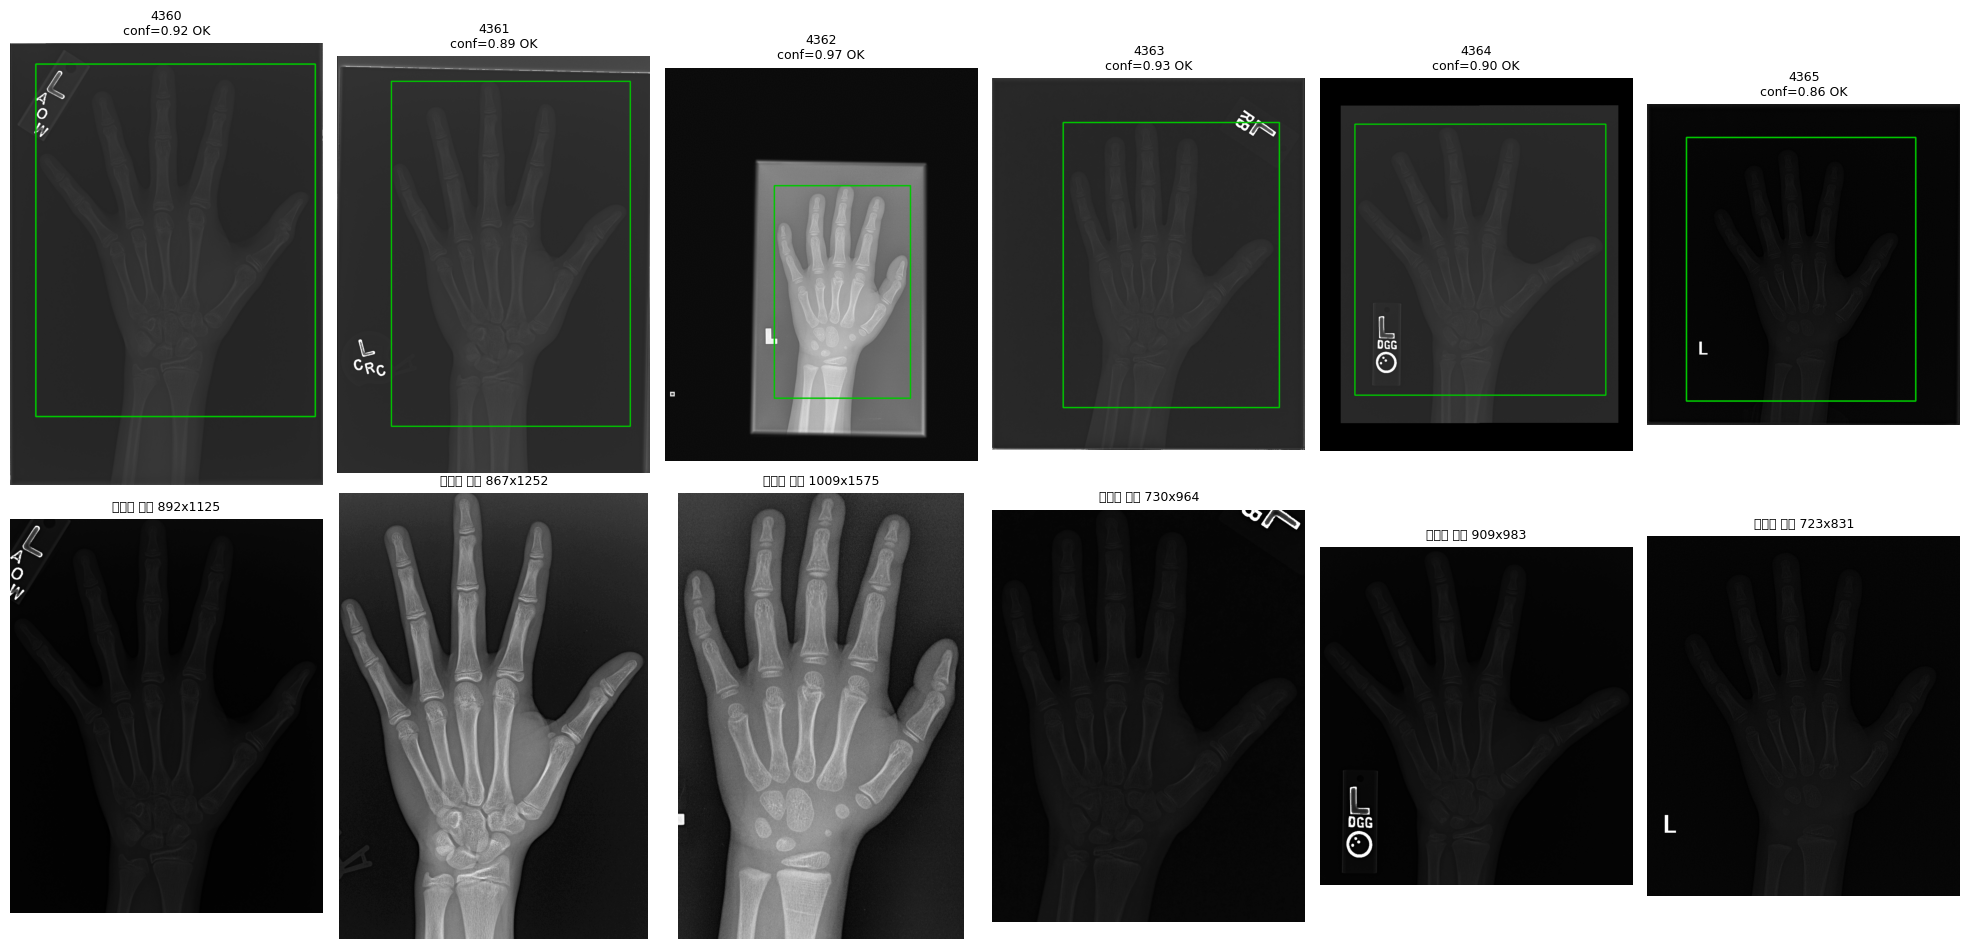

,image_id,conf,crop_w,crop_h,area_ratio,aspect,flags
0,4360,0.92480,892,1125,0.71040,1.2612,
1,4361,0.89111,867,1252,0.62988,1.4441,
2,4362,0.96924,1009,1575,0.23459,1.5610,
3,4363,0.92627,730,964,0.52923,1.3205,
4,4364,0.90137,909,983,0.58238,1.0814,
5,4365,0.85791,723,831,0.60151,1.1494,


In [4]:
def crop_from(img, result, name=""):
    """(크롭 이미지, 기록 dict) 반환. 검출 실패 시 원본 전체 + no_det 플래그."""
    H, W = img.shape[:2]
    boxes = parse_boxes(result)
    rec = dict(image_id=Path(name).stem, file_name=name, W=W, H=H, num_boxes=len(boxes))

    if not boxes:
        # 미검출은 'no_det' 하나만 남긴다 (원본 전체가 fallback이므로
        # huge_box/touch_border가 같이 붙으면 실제 원인이 묻힌다)
        rec.update(conf=0.0, x1=0, y1=0, x2=W, y2=H, crop_w=W, crop_h=H,
                   area_ratio=1.0, aspect=round(H / max(W, 1), 4),
                   flags="no_det", saved=False)
        return img, rec

    (bx1, by1, bx2, by2), cf, cid = boxes[0]
    x1, y1, x2, y2 = expand_box(bx1, by1, bx2, by2, W, H)
    flags, ar, asp = qc_check(cf, len(boxes), x1, y1, x2, y2, W, H)
    rec.update(conf=round(cf, 5), cls=cid, x1=x1, y1=y1, x2=x2, y2=y2,
               crop_w=x2 - x1, crop_h=y2 - y1, area_ratio=ar, aspect=asp,
               flags="|".join(flags), saved=False)
    return img[y1:y2, x1:x2], rec


def make_preview(img, rec, crop, max_h=PREVIEW_MAX_H):
    """원본+박스 | 크롭 을 가로로 이어붙인 검수 이미지"""
    vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    color = (0, 0, 255) if rec["flags"] else (0, 220, 0)
    th = max(2, min(vis.shape[:2]) // 250)
    cv2.rectangle(vis, (rec["x1"], rec["y1"]), (rec["x2"], rec["y2"]), color, th)

    cro = cv2.cvtColor(crop, cv2.COLOR_GRAY2BGR)
    s1, s2 = max_h / vis.shape[0], max_h / max(cro.shape[0], 1)
    vis = cv2.resize(vis, (int(vis.shape[1] * s1), max_h), interpolation=cv2.INTER_AREA)
    cro = cv2.resize(cro, (max(1, int(cro.shape[1] * s2)), max_h), interpolation=cv2.INTER_AREA)

    gap = np.zeros((max_h, 12, 3), np.uint8)
    out = np.hstack([vis, gap, cro])
    txt = f'{rec["image_id"]} conf={rec["conf"]:.2f} {rec["flags"] or "OK"}'
    cv2.putText(out, txt, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2, cv2.LINE_AA)
    return out


# ─── 예행 ────────────────────────────────────────────────────────
probe = FILES[:6]
imgs  = [imread_u(p) for p in probe]
res   = det.predict([to_bgr(im) for im in imgs], conf=CONF_TH, iou=IOU_TH, imgsz=IMGSZ,
                    device=DEVICE, half=USE_HALF, verbose=False, max_det=10)

fig, axes = plt.subplots(2, len(probe), figsize=(3.3 * len(probe), 9.5))
prev_recs = []
for j, (p, im, r) in enumerate(zip(probe, imgs, res)):
    crop, rec = crop_from(im, r, p.name)
    prev_recs.append(rec)
    vis = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
    cv2.rectangle(vis, (rec["x1"], rec["y1"]), (rec["x2"], rec["y2"]),
                  (255, 0, 0) if rec["flags"] else (0, 200, 0), max(3, im.shape[1] // 250))
    axes[0, j].imshow(vis[..., ::-1])
    axes[0, j].set_title(f'{p.stem}\nconf={rec["conf"]:.2f} {rec["flags"] or "OK"}', fontsize=9)
    out = finalize(crop)
    axes[1, j].imshow(out, cmap="gray")
    axes[1, j].set_title(f"저장될 크롭 {out.shape[1]}x{out.shape[0]}", fontsize=9)
    axes[0, j].axis("off"); axes[1, j].axis("off")
plt.tight_layout(); plt.show()

display(pd.DataFrame(prev_recs)[["image_id", "conf", "crop_w", "crop_h", "area_ratio", "aspect", "flags"]])


## Part 4. 전체 배치 크롭 저장

- 디스크 읽기 스레드 8개 + GPU 배치 16장 → I/O와 GPU가 서로 대기하지 않습니다.
- `SKIP_EXISTING=True`면 이미 저장된 파일은 건너뜁니다. **중단돼도 재실행하면 이어서** 진행됩니다.
- 예외가 나도 멈추지 않고 `errors.txt`에 기록하고 계속합니다.
- RTX 5060 + FP16 기준 12,611장에 **대략 8~15분** (디스크 속도에 좌우).

> `MARGIN`이나 `OUT_SIZE`를 바꿔 다시 돌릴 때는 `SKIP_EXISTING=False`로 두거나 `images/` 폴더를 비우세요. 안 그러면 옛 설정 결과가 섞입니다.


In [5]:
targets = FILES if LIMIT is None else FILES[:LIMIT]
if SKIP_EXISTING:
    targets = [p for p in targets if not (CROP_DIR / f"{p.stem}{SAVE_EXT}").exists()]
print(f"처리 대상 {len(targets):,}장 (전체 {len(FILES):,}장 중)")

records, errors = [], []

def _read(p):
    try:
        return p, imread_u(p), None
    except Exception as e:
        return p, None, f"{type(e).__name__}: {e}"

t0 = time.time(); n_saved = 0

with ThreadPoolExecutor(max_workers=READ_WORKERS) as pool, \
     tqdm(total=len(targets), desc="crop") as bar:

    for i in range(0, len(targets), BATCH):
        chunk  = targets[i:i + BATCH]
        loaded = list(pool.map(_read, chunk))

        ok = [(p, im) for p, im, err in loaded if im is not None]
        for p, im, err in loaded:
            if im is None:
                errors.append(f"{p.name}\tREAD\t{err}")
        if not ok:
            bar.update(len(chunk)); continue

        try:
            results = det.predict([to_bgr(im) for _, im in ok], conf=CONF_TH, iou=IOU_TH,
                                  imgsz=IMGSZ, device=DEVICE, half=USE_HALF,
                                  verbose=False, max_det=10)
        except Exception as e:
            for p, _ in ok:
                errors.append(f"{p.name}\tINFER\t{type(e).__name__}: {e}")
            bar.update(len(chunk)); continue

        for (p, im), r in zip(ok, results):
            try:
                crop, rec = crop_from(im, r, p.name)

                skip_save = ("no_det" in rec["flags"]) and (NO_DET_POLICY == "skip")
                if not skip_save and crop.size > 0:
                    out = finalize(crop)
                    imwrite_u(CROP_DIR / f"{p.stem}{SAVE_EXT}", out,
                              quality=JPG_QUALITY if SAVE_EXT.lower() in (".jpg", ".jpeg") else None)
                    rec["saved"] = True
                    rec["out_w"], rec["out_h"] = out.shape[1], out.shape[0]
                    n_saved += 1

                if SAVE_PREVIEW == "all" or (SAVE_PREVIEW == "flagged" and rec["flags"]):
                    imwrite_u(PREVIEW_DIR / f"{p.stem}.jpg", make_preview(im, rec, crop), quality=85)

                records.append(rec)
            except Exception as e:
                errors.append(f"{p.name}\tSAVE\t{type(e).__name__}: {e}")

        bar.update(len(chunk))

el = time.time() - t0
print(f"\n저장 {n_saved:,}장 / {el/60:.1f}분 ({n_saved/max(el,1e-9):.1f} img/s)")
print(f"예외 {len(errors)}건")
if errors:
    (BASE_OUT / "errors.txt").write_text("\n".join(errors), encoding="utf-8")
    for e in errors[:10]:
        print("  ", e)


처리 대상 200장 (전체 200장 중)


crop:   0%|          | 0/200 [00:00<?, ?it/s]

WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING 'half' is deprecated and

## Part 5. 결과 통계 + 크롭 사이즈 분포

`crop_log.csv`는 이번 실행분만 담깁니다. 나눠 실행했다면 이 셀이 `images/` 폴더 실제 파일 수와
원본 수를 비교해 **누락분을 알려줍니다.**

In [6]:
log = pd.DataFrame(records)
if len(log):
    log.to_csv(BASE_OUT / "crop_log.csv", index=False, encoding="utf-8-sig")
    fail = log[log.flags != ""]
    fail.to_csv(BASE_OUT / "crop_failed.csv", index=False, encoding="utf-8-sig")

    print(f"이번 실행 {len(log):,}장 | 저장 {int(log.saved.sum()):,}장")
    print(f"QC 플래그 {len(fail):,}건 ({len(fail)/len(log)*100:.2f}%)")
    if len(fail):
        from collections import Counter
        c = Counter(f for s in fail.flags for f in s.split("|"))
        for k, v in c.most_common():
            print(f"   {k:14s} {v:6,}")

    print("\n[크롭 통계]")
    display(log[["conf", "crop_w", "crop_h", "area_ratio", "aspect"]].describe().round(3))

    fig, ax = plt.subplots(1, 4, figsize=(19, 3.6))
    ax[0].hist(log.conf, bins=50, color="#3b7dd8"); ax[0].axvline(LOW_CONF, c="r", ls="--"); ax[0].set_title("confidence")
    ax[1].hist(log.area_ratio, bins=50, color="#3b7dd8")
    ax[1].axvline(MIN_AREA, c="r", ls="--"); ax[1].axvline(MAX_AREA, c="r", ls="--"); ax[1].set_title("area ratio")
    ax[2].hist(log.aspect, bins=50, color="#3b7dd8")
    ax[2].axvline(ASPECT_LO, c="r", ls="--"); ax[2].axvline(ASPECT_HI, c="r", ls="--"); ax[2].set_title("aspect (h/w)")
    ax[3].scatter(log.crop_w, log.crop_h, s=3, alpha=.25); ax[3].set_title("crop w vs h")
    plt.tight_layout(); plt.show()
else:
    print("이번 실행에서 새로 처리한 이미지가 없습니다 (전량 SKIP_EXISTING).")
    fail = pd.DataFrame()

# ─── 폴더 대조: 누락분 확인 ──────────────────────────────────────
saved_ids = {p.stem for p in CROP_DIR.glob(f"*{SAVE_EXT}")}
src_ids   = {p.stem for p in FILES}
missing   = sorted(src_ids - saved_ids)

print(f"\n원본 {len(src_ids):,} / 저장 {len(saved_ids):,} / 누락 {len(missing):,}")
if missing:
    (BASE_OUT / "missing_ids.txt").write_text("\n".join(missing), encoding="utf-8")
    print("  누락 목록 →", BASE_OUT / "missing_ids.txt")
    print("  예시:", missing[:10])


KeyError: True

## Part 6. 실패·QC 케이스 검수

12,611장을 전부 볼 수는 없으니 문제 후보만 골라 봅니다.
왼쪽이 원본+박스, 오른쪽이 저장된 크롭입니다. `no_det` → `huge_box` → `low_conf` 순으로 심각합니다.

In [ ]:
SHOW_FLAG = None    # "no_det" / "huge_box" / "small_box" ... None이면 전체
SHOW_N    = 8

src = fail if len(fail) else pd.DataFrame()
if len(src) and SHOW_FLAG:
    src = src[src.flags.str.contains(SHOW_FLAG)]

if not len(src):
    print("표시할 QC 케이스가 없습니다.")
else:
    src = src.assign(prio=src.flags.apply(
            lambda f: 0 if "no_det" in f else 1 if "huge_box" in f else 2 if "low_conf" in f else 3)
         ).sort_values(["prio", "conf"]).head(SHOW_N)

    for _, r in src.iterrows():
        pv = PREVIEW_DIR / f"{r.image_id}.jpg"
        img = imread_u(pv, cv2.IMREAD_COLOR) if pv.exists() else None
        if img is None:      # preview를 안 남긴 모드면 즉석 생성
            im = imread_u(SRC_DIR / r.file_name)
            crop = im[int(r.y1):int(r.y2), int(r.x1):int(r.x2)]
            img = make_preview(im, r.to_dict(), crop)
        plt.figure(figsize=(13, 6))
        plt.imshow(img[..., ::-1]); plt.axis("off")
        plt.title(f"{r.image_id} | conf={r.conf:.2f} | {r.flags}", color="crimson")
        plt.show()

    display(src[["image_id", "conf", "crop_w", "crop_h", "area_ratio", "aspect", "flags"]].round(3))


---
## 실행 순서

1. **Part 0~1** → 이미지 수·`best.pt` 경로 확인
2. **Part 2**에서 `LIMIT = 50`으로 두고 **Part 3~4** 예행
3. Part 3 그림에서 잘림 여부 확인 → 필요하면 `MARGIN` 조정 후 재실행
4. `LIMIT = None`, `SKIP_EXISTING = False`, `images/` 비우고 **Part 4** 전체 실행
5. **Part 5~6**에서 누락 0건 · `no_det` 케이스 직접 확인

## 판정 기준

| 항목 | 정상 | 벗어나면 |
|---|---|---|
| 검출 성공률 | ≥ 99.5% | `CONF_TH`를 0.15로 낮춰 재실행 |
| conf 중앙값 | ≥ 0.90 | 실패 케이스를 Roboflow에 추가 라벨링 → 재학습 |
| aspect 중앙값 | 1.2~2.0 | 값이 크면 전완 포함, 작으면 손가락 잘림 |
| 누락 | 0건 | `errors.txt`·`missing_ids.txt` 확인 |

## 다음 단계

- Bone Age 학습 스크립트의 `BASE_DIR`을 `전처리\train\images`로 바꾸고, 기존 `_adv_select_hand()` 호출을 제거하세요. 크롭이 이미 끝난 상태이므로 전처리 캐시는 CLAHE·리사이즈·정규화만 담당하게 됩니다.
- validation(1,425장)·test(200장)에도 **동일 설정으로** 돌려야 합니다. 크롭 기준이 스플릿마다 다르면 그 자체가 분포 이동이 됩니다.
- 논문 재현 실험에서는 이 크롭이 논문 미명시 요소이므로 `PAPER_STRICT` 토글로 분리해 기록하세요.
